# 📊 Sales Analysis Report
### From Data to Decisions: A Journey Through Orders, Customers & Markets

This analysis explores a global orders dataset covering **July 2012 to May 2014**, 
examining sales patterns across cities, countries, customers, and time.

In [138]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import plotly.express as px

def wrangle (filename, encoding = None, dropna_columnnames = None, change_column_name= None, date_column= None, remove_duplicated_rows_columnsname = None):
    # Loading Data from csv file
    df = pd.read_csv(filename, encoding= encoding)
    ### Get Orders NaN Rows
    df.dropna(subset= dropna_columnnames, inplace=True)

    # Rename Columns
    df = df.rename(columns= change_column_name)
    
    # Change OrderDate and ID Columns type to Date, integer
    df[date_column] = pd.to_datetime(df[date_column])    

    #Drop dupliacted rows
    df = df.drop_duplicates(subset= remove_duplicated_rows_columnsname)

       
    #Strip and lowercase columns names
    df.columns = df.columns.str.strip().str.lower()
    
    for col in df.columns:
        if 'id' in col or 'ordernumber' in col:
            df[col] = df[col].astype(int)
    return df 


orders = wrangle('all_data.csv', encoding= 'latin-1' , 
                 dropna_columnnames= ['OrderID'], 
                 change_column_name= {'City.1' : 'SuppCity', 'Country.1' : 'SuppCountry', 'Phone.1' : 'Supp_Phone'}, 
                 date_column= 'OrderDate', 
                 remove_duplicated_rows_columnsname= ['OrderID'])
orders = orders[['customerid', 'firstname', 'lastname', 'city', 'country', 'orderid', 'ordernumber', 'orderdate', 'totalamount']]


# Univariate Data

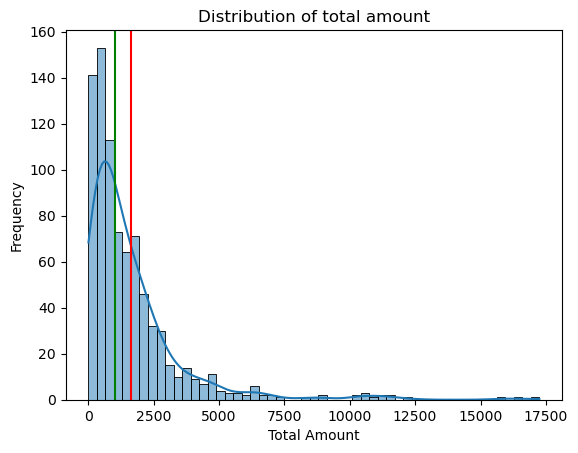

In [139]:
sns.histplot(orders['totalamount'], kde=True)
plt.title("Distribution of total amount")
plt.xlabel("Total Amount")
plt.ylabel("Frequency")
plt.axvline(orders.totalamount.mean(), color="red")
plt.axvline(orders.totalamount.median(), color="green")
plt.show()

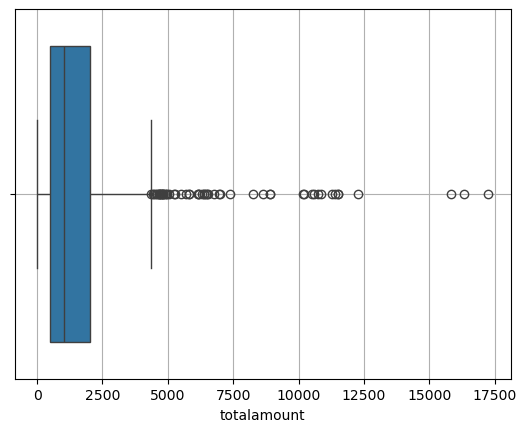

In [140]:
sns.boxplot(data=orders , x=orders.totalamount)
plt.grid()

In [141]:
ordesr = orders[orders['totalamount'] < 15000]

## 💡 What Does a Typical Order Look Like?

Most orders fall between modest amounts, but the distribution is **right-skewed** — 
a small number of very large orders pull the mean above the median. 
The red line (mean) sits noticeably higher than the green (median), 
signaling that a few big spenders significantly inflate the average.

> *High-value outliers exist — and they matter for revenue.*

In [142]:
px.bar(orders['city'].value_counts(), title="distribution of cities")

In [143]:
px.bar(orders['country'].value_counts(), title="distribution of contries")


In [144]:
px.pie(data_frame=orders, names='country')

## 🌍 Where Are Our Customers?

**London dominates** city-level orders (~45), followed by Rio de Janeiro and São Paulo. 
At the country level, **Germany and the USA lead neck-and-neck (~120 orders each)**, 
with Brazil and France as strong challengers.

Interestingly, **London tops cities yet UK ranks only 5th by country** — 
British demand is hyper-concentrated in a single city.

> *Focus markets: Germany, USA, Brazil, France. Watch: Venezuela, Mexico.*

# Bivariate Analysis

#### country and tottal amount
#### city and tottal  amount

In [145]:
def plots(columnname, top10= False):
    prop = orders.groupby(columnname, as_index=False)['totalamount'].sum().sort_values('totalamount',ascending=False)
    prop['proper'] = (prop.totalamount / orders.totalamount.sum()) * 100
    prop = prop.sort_values(by='proper', ascending=False)
    print("Describe of all Toatal amount valeus ", prop.totalamount.describe())
    if top10:
        prop = prop.head(10)
    fig1 = px.bar(data_frame=prop, x = columnname, y='totalamount')
    fig2 = px.pie(data_frame=prop, names=columnname, values='totalamount')
    fig1.show()
    fig2.show()


In [146]:
plots('country')

Describe of all Toatal amount valeus  count        21.000000
mean      64498.028095
std       72328.731450
min        3531.950000
25%       19431.890000
50%       35134.980000
75%       60814.890000
max      263566.980000
Name: totalamount, dtype: float64


In [147]:
plots('city', True)

Describe of all Toatal amount valeus  count        69.000000
mean      19629.834638
std       24804.361376
min         357.000000
25%        4788.060000
50%       11830.100000
75%       23850.950000
max      117483.390000
Name: totalamount, dtype: float64


## 💰 Who Spends the Most?

Order count and revenue tell **different stories**. 
While Germany and USA lead in volume, **Austria punches well above its weight in revenue** 
relative to order count — suggesting high-value customers there.

Cunewalde (Germany) tops cities by total amount despite not leading in order count, 
pointing to a **concentrated, high-spending customer base**.

## Date and totalamount

In [148]:
date_total = orders[['orderdate', 'totalamount']]
date_total = date_total.set_index('orderdate')
px.line(data_frame=date_total)

## Data and Country

In [149]:
date_country = orders[['orderdate', 'country']]
date_country = date_country.set_index('orderdate')
date_country = date_country.country.resample(rule='1ME').nunique()

In [150]:
px.line(data_frame=date_country, y='country')

## Customers and Totalamount

In [151]:
cust_orders = {
    "fullname" : orders.firstname + " " + orders.lastname,
    "totalamount" : orders.totalamount
}
cust_orders = pd.DataFrame(cust_orders)


In [152]:
fig = px.bar(cust_orders.groupby('fullname')['totalamount'].count().sort_values(ascending=False).head(10), text_auto=True, title="Number of orders per customer",
labels={'fullname' : "Full Name", "value" : "Frequency"})
fig.update_traces(marker_color="skyblue", marker_line_color='grey', marker_line_width=1.5, opacity=0.5, textposition='outside')
fig.show()

In [153]:
fig = px.bar(cust_orders.groupby('fullname')['totalamount'].sum().sort_values(ascending=False).head(10), text_auto=True, title="Number of orders per customer",
labels={'fullname' : "Full Name", "value" : "Total Amount"})
fig.update_traces(marker_color="skyblue", marker_line_color='grey', marker_line_width=1.5, opacity=0.5, textposition='outside')
fig.show()

## 🏆 Our Most Valuable Customers

**Jose Pavarotti** places the most orders (31), but **Horst Kloss** 
generates the highest total revenue — a classic frequency vs. value tradeoff.

These top 10 customers represent a **critical segment worth protecting**. 
Losing even one of them would have a measurable impact on overall revenue.

# Multivariate Analysis

#### we intersting in knowing tje number of countries and the grand total amount of them per month

In [154]:
multivar = orders[['orderdate', 'country', 'totalamount']]
multivar = multivar.set_index('orderdate')
multivar = multivar.resample('ME').agg({'country' : 'nunique', 'totalamount' : 'sum'})
# multivar

In [155]:
fig = px.bar(data_frame=multivar, x =  multivar.index, y =round(multivar.totalamount, 0), color=multivar.country, text_auto=True,
             title='Grand total amount of all countries per month', labels={'orderdate' : 'Order Date', 'y': 'Total Amount'})
fig.update_layout(title_x=0.5)
fig.show()

## 📅 Revenue Is Growing — With One Caveat

Monthly total sales show a **clear upward trend** from mid-2012 through early 2014, 
with the color scale showing increasing geographic diversity over time.

⚠️ **The last month (May 2014) shows a sharp drop — but this is misleading.** 
The dataset ends on May 6, 2014, meaning we only have 6 days of data for that month. 
*Always verify data completeness before drawing conclusions from the most recent period.*

#### Grand tota amount of each contry per month

In [156]:
multivar = orders[['orderdate', 'country', 'totalamount']]
multivar['orderdate'] = multivar['orderdate'].dt.to_period('M')
# multivar.info()

In [157]:
multivar = multivar.groupby(['orderdate', 'country'], as_index=False)['totalamount'].sum().sort_values(by='totalamount', ascending=False)
multivar['orderdate']  = multivar['orderdate'].astype('datetime64[ns]')

In [158]:
px.scatter(data_frame=multivar, x=multivar.orderdate, y='totalamount', color='country', size="totalamount")

## 🔵 Country Revenue Over Time

The bubble chart reveals the **dominance of USA and Germany** month after month — 
consistent large bubbles throughout the timeline. 

Austria shows **sporadic large spikes** followed by silence, 
confirming it's driven by a handful of high-value customers rather than steady volume.

> *Consistent = Germany/USA. Volatile = Austria, Ireland. Emerging = Venezuela, Mexico.*

In [164]:
orders['orderdate'].max()

Timestamp('2014-05-06 00:00:00')

The last recorded order is on **May 6, 2014** — only 6 days into the month.
This confirms May 2014 is **incomplete** and should be excluded from any trend analysis.

In [173]:
austria = orders[orders["country"] == "Austria"]
austria = austria.groupby(['firstname', 'lastname'])['totalamount'].agg(['sum', 'count']).sort_values('sum', ascending=False)
austria

,,sum,count
firstname,lastname,,
Roland,Mendel,113236.68,30
Georg,Pipps,26259.95,10


In [185]:
customer_counts = orders[orders['country'].isin(['Austria', 'USA', 'Germany'])].groupby('country')['customerid'].nunique().reset_index()
customer_counts.columns = ['country', 'customer_count']
customer_counts
px.bar(customer_counts, x='country', y='customer_count', color='country', text_auto=True, title='Number of Unique Customers per Country')

## 📝 Note

Austria has only **2 customers** which explains the volatile sales pattern.
USA and Germany have more customers but still a small base, 
making **customer retention critical** for all three markets.